In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

import keras
from keras import layers
from keras import ops
from tensorflow.keras.models import Sequential
import keras_tuner as kt

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import random
import time
import seaborn as sns

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1775969373.227648 3364756 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775969373.859963 3364756 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Load L2-normalized waveforms (X_euclidean is pre-computed in preprocess.py).
# L2 is a per-waveform operation that makes every pulse a unit vector, stripping
# amplitude while preserving shape. No further scaling is needed.
d = np.load("processed_waveforms.npz")
X = d["X_euclidean"].astype(np.float32)   # (N, 104), each row has ||x||_2 = 1
y = d["y"].astype(np.int32)               # 0 = photon, 1 = neutron

# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

# Add channel dimension for Conv1D: (N, 104) -> (N, 104, 1)
X_train_n = X_train[..., np.newaxis]
X_test_n  = X_test[..., np.newaxis]

print(f"Train: {X_train_n.shape}   Test: {X_test_n.shape}")
print(f"Train class counts: photon={(Y_train==0).sum():,}  neutron={(Y_train==1).sum():,}")
print(f"L2 norm check: train norms mean = {np.linalg.norm(X_train_n.squeeze(-1), axis=1).mean():.4f}")

Train: (416008, 104, 1)   Test: (104002, 104, 1)
Train class counts: photon=203,021  neutron=212,987
L2 norm check: train norms mean = 1.0000


In [3]:
input_length = np.shape(X_train_n)[1]
latent_dim = 8
inputs = tf.keras.Input(shape=(input_length, 1))

#  Encoder 
x = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(2, padding='same')(x)   
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)  
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)   
shape = x.shape[1:]  

# Feature vector 
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, name="latent")(x) #Flatten into latent dimension

#  Decoder (input is feature vector) 
x = layers.Dense(shape[0] * shape[1], activation='relu')(latent)
x = layers.Reshape(shape)(x)
x = layers.UpSampling1D(2)(x)  
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(2)(x)  
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(2)(x)  
x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)

#Reconstructed Signal 
reconstruction = layers.Conv1D(1, 3, padding='same', name="reconstruction")(x)

#  Classifier 
clf = layers.Dense(32, activation='relu')(latent)
clf = layers.Dense(16, activation='relu')(clf)
classification = layers.Dense(1, activation='sigmoid', name="classification")(clf)

# Full Model 
model = Model(inputs, [reconstruction, classification])

I0000 00:00:1775969375.594673 3364756 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1276 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [4]:
model.compile(
    optimizer='adam',
    loss={
        'reconstruction': 'mse',
        'classification': 'binary_crossentropy'},
    loss_weights={
        'reconstruction': 1.0,
        'classification': 1.0},
    metrics={
        'classification': ['accuracy']})

In [5]:
history = model.fit(
    X_train_n,
    {
        "reconstruction": X_train_n,
        "classification": Y_train},
    validation_data=(
        X_test_n,
        {
            "reconstruction": X_test_n,
            "classification": Y_test}
    ),
    epochs=50,
    batch_size=512
)

Epoch 1/50


I0000 00:00:1775969377.276952 3364942 service.cc:153] XLA service 0x78e54c03c910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775969377.276969 3364942 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.8.0; DNN: 9.19.0)
I0000 00:00:1775969377.307731 3364942 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775969377.546086 3364942 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1775969377.557160 3364942 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4948__.47
W0000 00:00:1775969388.213916 3365066 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.12GiB (rounded to 6570402560)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will imp

 41/813 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - classification_accuracy: 0.6785 - classification_loss: 0.6400 - loss: 0.6447 - reconstruction_loss: 0.0047

I0000 00:00:1775969410.275335 3364942 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


810/813 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - classification_accuracy: 0.9440 - classification_loss: 0.1395 - loss: 0.1404 - reconstruction_loss: 8.6808e-04

I0000 00:00:1775969413.603708 3364942 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4948__.47
I0000 00:00:1775969413.903670 3372065 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_12', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1775969414.054805 3372066 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 20 bytes spill stores, 24 bytes spill loads

I0000 00:00:1775969414.081266 3372055 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_12', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775969414.086470 3372050 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775969414.524859 3372056 subprocess_compil

813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - classification_accuracy: 0.9441 - classification_loss: 0.1392 - loss: 0.1400 - reconstruction_loss: 8.6616e-04

I0000 00:00:1775969436.407780 3364942 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10487__.14
W0000 00:00:1775969446.530959 3373259 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.34GiB (rounded to 2512061184)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1775969446.530999 3373259 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1775969446.531000 3373259 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 68, Chunks in use: 68. 17.0KiB allocated for chunks. 17.0KiB in use in bin. 3.4KiB client-requested in use in bin.
I0000 00:00:1775969446.531006 3373259 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 12, Chunks in use: 12. 6.0KiB allocated for chunks. 6.0KiB in use in bin. 5.2KiB client-requested in use in bin.
I0000 

813/813 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - classification_accuracy: 0.9795 - classification_loss: 0.0546 - loss: 0.0549 - reconstruction_loss: 3.4594e-04 - val_classification_accuracy: 0.9893 - val_classification_loss: 0.0269 - val_loss: 0.0271 - val_reconstruction_loss: 1.5655e-04
Epoch 2/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - classification_accuracy: 0.9916 - classification_loss: 0.0207 - loss: 0.0208 - reconstruction_loss: 1.4984e-04 - val_classification_accuracy: 0.9931 - val_classification_loss: 0.0172 - val_loss: 0.0173 - val_reconstruction_loss: 1.4741e-04
Epoch 3/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - classification_accuracy: 0.9925 - classification_loss: 0.0182 - loss: 0.0183 - reconstruction_loss: 1.4553e-04 - val_classification_accuracy: 0.9923 - val_classification_loss: 0.0180 - val_loss: 0.0182 - val_reconstruction_loss: 1.4371e-04
Epoch 4/50
813/813 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - classification_accuracy: 0.9931 - classification_loss: 0.0166 - loss: 0.0

I0000 00:00:1775969612.913181 3364942 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_313252__.7
I0000 00:00:1775969613.141173 3385155 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 4 bytes spill stores, 4 bytes spill loads



3241/3251 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step

I0000 00:00:1775969614.849918 3364943 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_323318__.7


3251/3251 ━━━━━━━━━━━━━━━━━━━━ 3s 590us/step


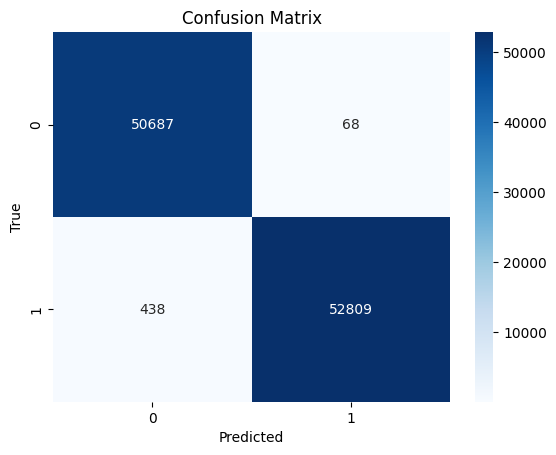

In [6]:
import os; os.makedirs("figures", exist_ok=True)
# Get predictions
y_pred = model.predict(X_test_n)[1]

# Convert probabilities to binary
y_pred_bin = (y_pred > 0.5).astype(int)

# Plot confusion matrix for each label
cm = confusion_matrix(Y_test, y_pred_bin)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig("figures/a1_multitask_old_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

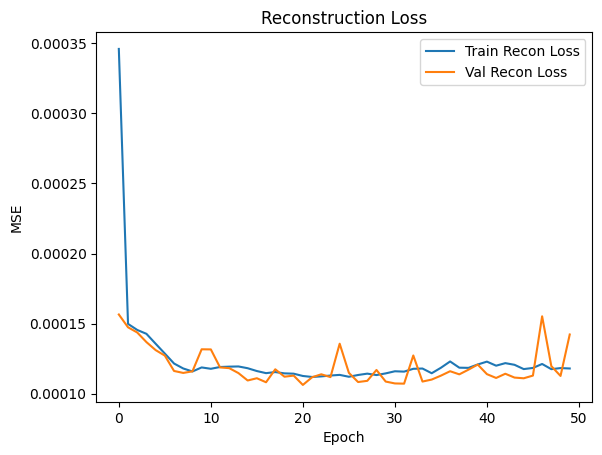

In [7]:
plt.figure()
plt.plot(history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig("figures/a1_multitask_old_reconstruction_loss.png", dpi=120, bbox_inches="tight")
plt.show()

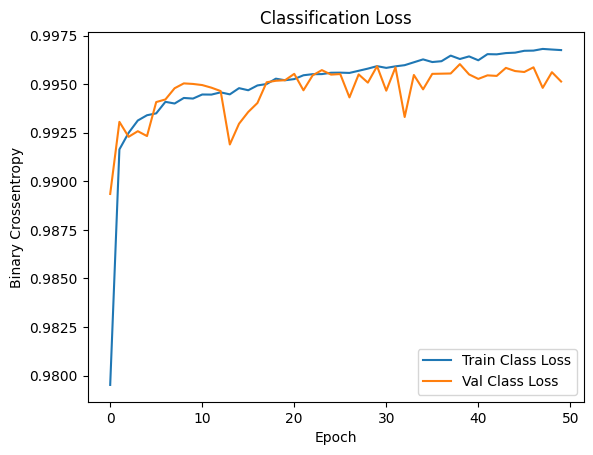

In [8]:
plt.figure()
plt.plot(history.history['classification_accuracy'], label='Train Class Loss')
plt.plot(history.history['val_classification_accuracy'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.savefig("figures/a1_multitask_old_classification_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()

## Tuned CNN Autoencoder (from a1_tune.ipynb)

Below we rebuild the autoencoder using the best-scoring CNN configuration from the hyperparameter search, keeping the same dense classifier. This lets us compare the hand-designed architecture above with the tuned one on identical train/test data.

**Tuned configuration (rank 1 CNN, composite score 0.00592):**

| Hyperparameter | Value |
|---|---|
| latent_dim | 8 |
| n_conv_layers | 2 (stride-2 Conv1D) |
| kernel_size | 3 |
| n_filters_start | 32 (doubling → filters = [32, 64]) |
| activation | elu |
| output_activation | linear |
| dropout | 0.0 |
| l2_reg | 1e-4 |
| batch_norm | False |
| noise_std | 0.0 |
| optimizer | Nadam |
| learning_rate | 1e-3 |
| batch_size | 1024 |
| reconstruction loss | huber |
| n_params | 40,905 |
| val accuracy (search) | 98.94% |

In [9]:
from tensorflow.keras import regularizers

input_length = np.shape(X_train_n)[1]
latent_dim_tuned = 8
l2_reg = regularizers.l2(1e-4)

tuned_inputs = tf.keras.Input(shape=(input_length, 1))

# Encoder: 2 stride-2 Conv1D layers, doubling filters (32 -> 64), kernel=3, elu
x = layers.Conv1D(32, 3, strides=2, padding='same', kernel_regularizer=l2_reg)(tuned_inputs)
x = layers.Activation('elu')(x)
x = layers.Conv1D(64, 3, strides=2, padding='same', kernel_regularizer=l2_reg)(x)
x = layers.Activation('elu')(x)

pre_flat_shape = x.shape[1:]  # (26, 64)
flat_size = int(pre_flat_shape[0] * pre_flat_shape[1])

# Latent bottleneck
x = layers.Flatten()(x)
tuned_latent = layers.Dense(latent_dim_tuned)(x)
tuned_latent = layers.Activation('elu', name='latent_tuned')(tuned_latent)

# Decoder: mirror the encoder with Conv1DTranspose
x = layers.Dense(flat_size)(tuned_latent)
x = layers.Activation('elu')(x)
x = layers.Reshape(pre_flat_shape)(x)
x = layers.Conv1DTranspose(32, 3, strides=2, padding='same', kernel_regularizer=l2_reg)(x)
x = layers.Activation('elu')(x)
tuned_reconstruction = layers.Conv1DTranspose(
    1, 3, strides=2, padding='same', activation='linear', name='reconstruction'
)(x)

# Classifier: same dense stack as before (Dense 32 -> 16 -> 1)
clf = layers.Dense(32, activation='relu')(tuned_latent)
clf = layers.Dense(16, activation='relu')(clf)
tuned_classification = layers.Dense(1, activation='sigmoid', name='classification')(clf)

tuned_model = Model(tuned_inputs, [tuned_reconstruction, tuned_classification])

tuned_model.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=1e-3),
    loss={
        'reconstruction': keras.losses.Huber(),
        'classification': 'binary_crossentropy',
    },
    loss_weights={'reconstruction': 1.0, 'classification': 1.0},
    metrics={'classification': ['accuracy']},
)
tuned_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 104, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 52, 32)    │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 52, 32)    │          0 │ conv1d_6[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 26, 64)    │      6,208 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 26, 64)    │          0 │ conv1d_7[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1664)      │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │     13,320 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_tuned        │ (None, 8)         │          0 │ dense_3[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1664)      │     14,976 │ latent_tuned[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1664)      │          0 │ dense_4[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 26, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose    │ (None, 52, 32)    │      6,176 │ reshape_1[0][0]   │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │        288 │ latent_tuned[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 52, 32)    │          0 │ conv1d_transpose… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │        528 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction      │ (None, 104, 1)    │         97 │ activation_3[0][… │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 1)         │         17 │ dense_6[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,738 (163.04 KB)

 Trainable params: 41,738 (163.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
tuned_history = tuned_model.fit(
    X_train_n,
    {
        'reconstruction': X_train_n,
        'classification': Y_train,
    },
    validation_data=(
        X_test_n,
        {
            'reconstruction': X_test_n,
            'classification': Y_test,
        }
    ),
    epochs=50,
    batch_size=1024,
)

Epoch 1/50


I0000 00:00:1775969617.852623 3364942 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_360864__.21
E0000 00:00:1775969618.797716 3385553 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775969618.912819 3385556 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775969618.985264 3385556 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


378/407 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - classification_accuracy: 0.9066 - classification_loss: 0.2598 - loss: 0.2677 - reconstruction_loss: 9.3793e-04

I0000 00:00:1775969621.059471 3364943 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_360864__.21
I0000 00:00:1775969621.235617 3385971 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 20 bytes spill stores, 24 bytes spill loads

I0000 00:00:1775969621.237878 3385980 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775969621.474304 3385966 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 8 bytes spill stores, 8 bytes spill loads



407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - classification_accuracy: 0.9110 - classification_loss: 0.2484 - loss: 0.2562 - reconstruction_loss: 8.9755e-04

I0000 00:00:1775969623.296637 3364943 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_363853__.12
I0000 00:00:1775969623.759829 3364933 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_363853__.12
I0000 00:00:1775969623.912660 3386349 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775969624.003125 3386353 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 20 bytes spill stores, 24 bytes spill loads



407/407 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - classification_accuracy: 0.9687 - classification_loss: 0.0970 - loss: 0.1035 - reconstruction_loss: 3.6282e-04 - val_classification_accuracy: 0.9911 - val_classification_loss: 0.0227 - val_loss: 0.0276 - val_reconstruction_loss: 1.2612e-04
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - classification_accuracy: 0.9917 - classification_loss: 0.0214 - loss: 0.0254 - reconstruction_loss: 1.2112e-04 - val_classification_accuracy: 0.9903 - val_classification_loss: 0.0240 - val_loss: 0.0273 - val_reconstruction_loss: 1.1639e-04
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - classification_accuracy: 0.9924 - classification_loss: 0.0191 - loss: 0.0220 - reconstruction_loss: 1.1639e-04 - val_classification_accuracy: 0.9926 - val_classification_loss: 0.0181 - val_loss: 0.0206 - val_reconstruction_loss: 1.1164e-04
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - classification_accuracy: 0.9927 - classification_loss: 0.0180 - loss: 0.02

I0000 00:00:1775969661.498784 3364935 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_516508__.1
I0000 00:00:1775969661.676374 3393015 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 4 bytes spill stores, 4 bytes spill loads



3250/3251 ━━━━━━━━━━━━━━━━━━━━ 0s 355us/step

I0000 00:00:1775969663.095299 3364935 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_526436__.1


3251/3251 ━━━━━━━━━━━━━━━━━━━━ 2s 488us/step


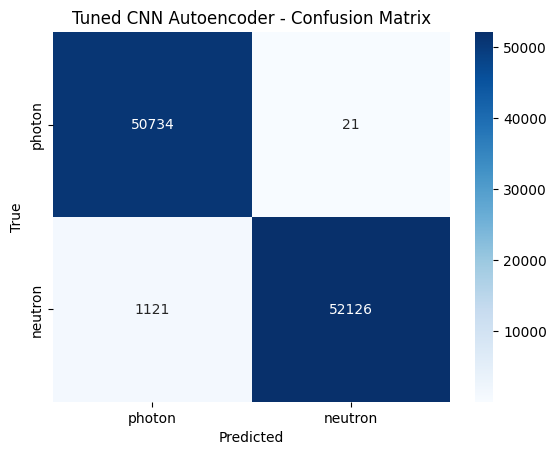

In [11]:
# Confusion matrix for the tuned model
y_pred_tuned = tuned_model.predict(X_test_n)[1]
y_pred_tuned_bin = (y_pred_tuned > 0.5).astype(int)

cm_tuned = confusion_matrix(Y_test, y_pred_tuned_bin)
plt.figure()
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['photon', 'neutron'], yticklabels=['photon', 'neutron'])
plt.title('Tuned CNN Autoencoder - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig("figures/a1_multitask_tuned_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## Before / After Comparison

Side-by-side figures comparing the hand-designed autoencoder (left) with the tuned CNN autoencoder (right).

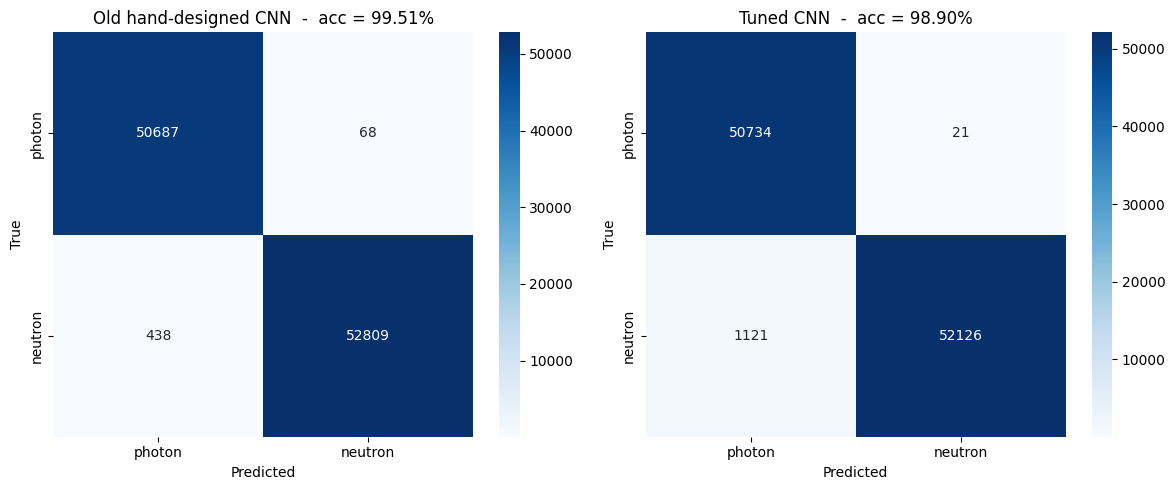

Old classification accuracy:   99.51%
Tuned classification accuracy: 98.90%
Improvement:                   -0.61 pp


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_old = confusion_matrix(Y_test, y_pred_bin)
cm_new = confusion_matrix(Y_test, y_pred_tuned_bin)

sns.heatmap(cm_old, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['photon', 'neutron'], yticklabels=['photon', 'neutron'])
acc_old = cm_old.diagonal().sum() / cm_old.sum()
axes[0].set_title(f'Old hand-designed CNN  -  acc = {acc_old*100:.2f}%')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['photon', 'neutron'], yticklabels=['photon', 'neutron'])
acc_new = cm_new.diagonal().sum() / cm_new.sum()
axes[1].set_title(f'Tuned CNN  -  acc = {acc_new*100:.2f}%')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig("figures/a1_multitask_compare_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

print(f'Old classification accuracy:   {acc_old*100:.2f}%')
print(f'Tuned classification accuracy: {acc_new*100:.2f}%')
print(f'Improvement:                   {(acc_new-acc_old)*100:+.2f} pp')

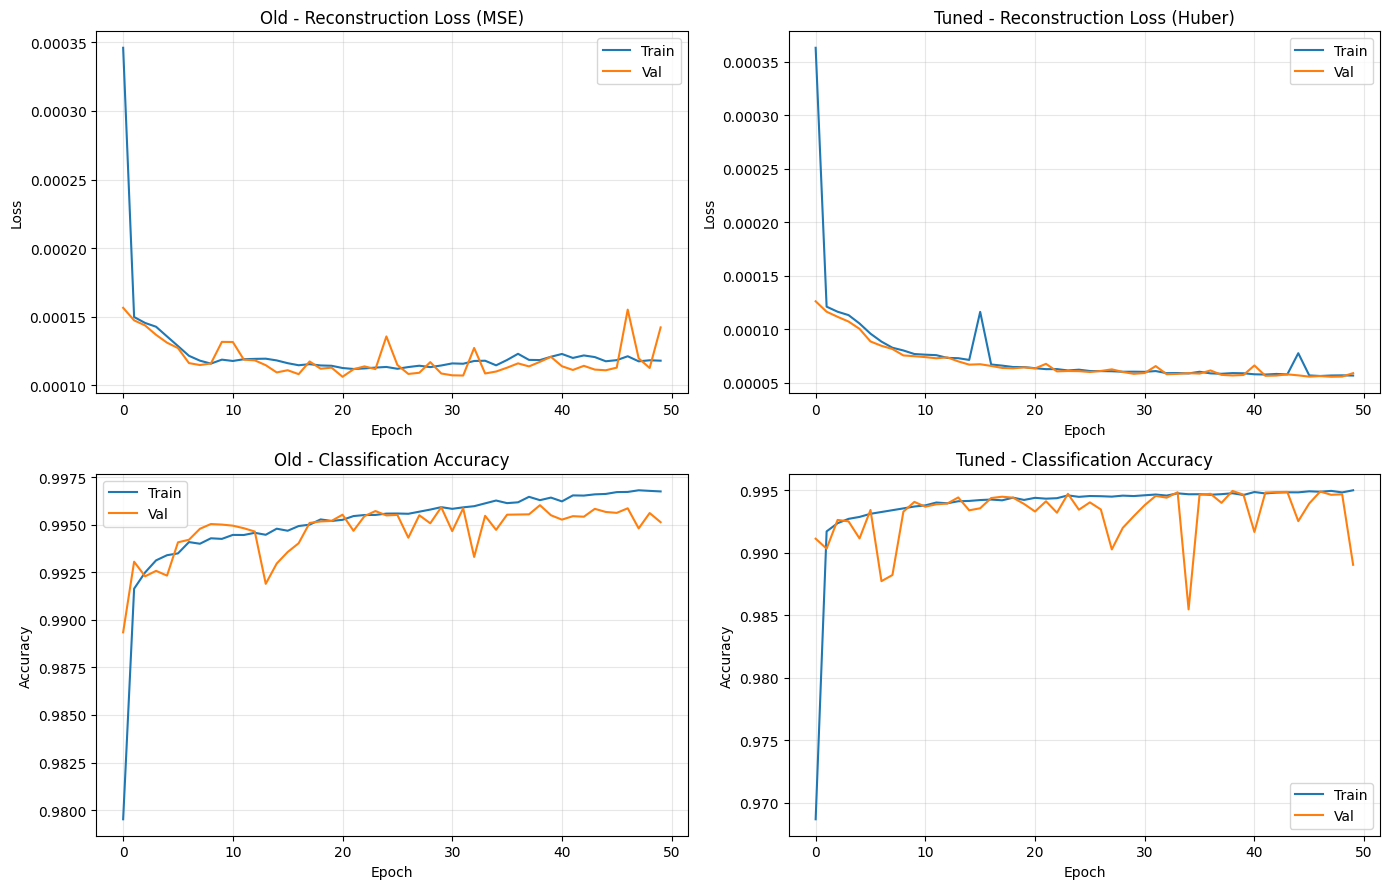

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Row 1: reconstruction loss
axes[0, 0].plot(history.history['reconstruction_loss'], label='Train')
axes[0, 0].plot(history.history['val_reconstruction_loss'], label='Val')
axes[0, 0].set_title('Old - Reconstruction Loss (MSE)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(tuned_history.history['reconstruction_loss'], label='Train')
axes[0, 1].plot(tuned_history.history['val_reconstruction_loss'], label='Val')
axes[0, 1].set_title('Tuned - Reconstruction Loss (Huber)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Row 2: classification accuracy
axes[1, 0].plot(history.history['classification_accuracy'], label='Train')
axes[1, 0].plot(history.history['val_classification_accuracy'], label='Val')
axes[1, 0].set_title('Old - Classification Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(tuned_history.history['classification_accuracy'], label='Train')
axes[1, 1].plot(tuned_history.history['val_classification_accuracy'], label='Val')
axes[1, 1].set_title('Tuned - Classification Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/a1_multitask_compare_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## Reconstruction visualizations

Random test waveforms reconstructed by each autoencoder, plotted in raw voltage (or L2-normalized space if `X_norms` isn't in the NPZ yet). Hand-designed model in blue, tuned model in orange, original in black.

I0000 00:00:1775969664.750998 3364933 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_323318__.7
I0000 00:00:1775969665.275201 3364938 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_526436__.1


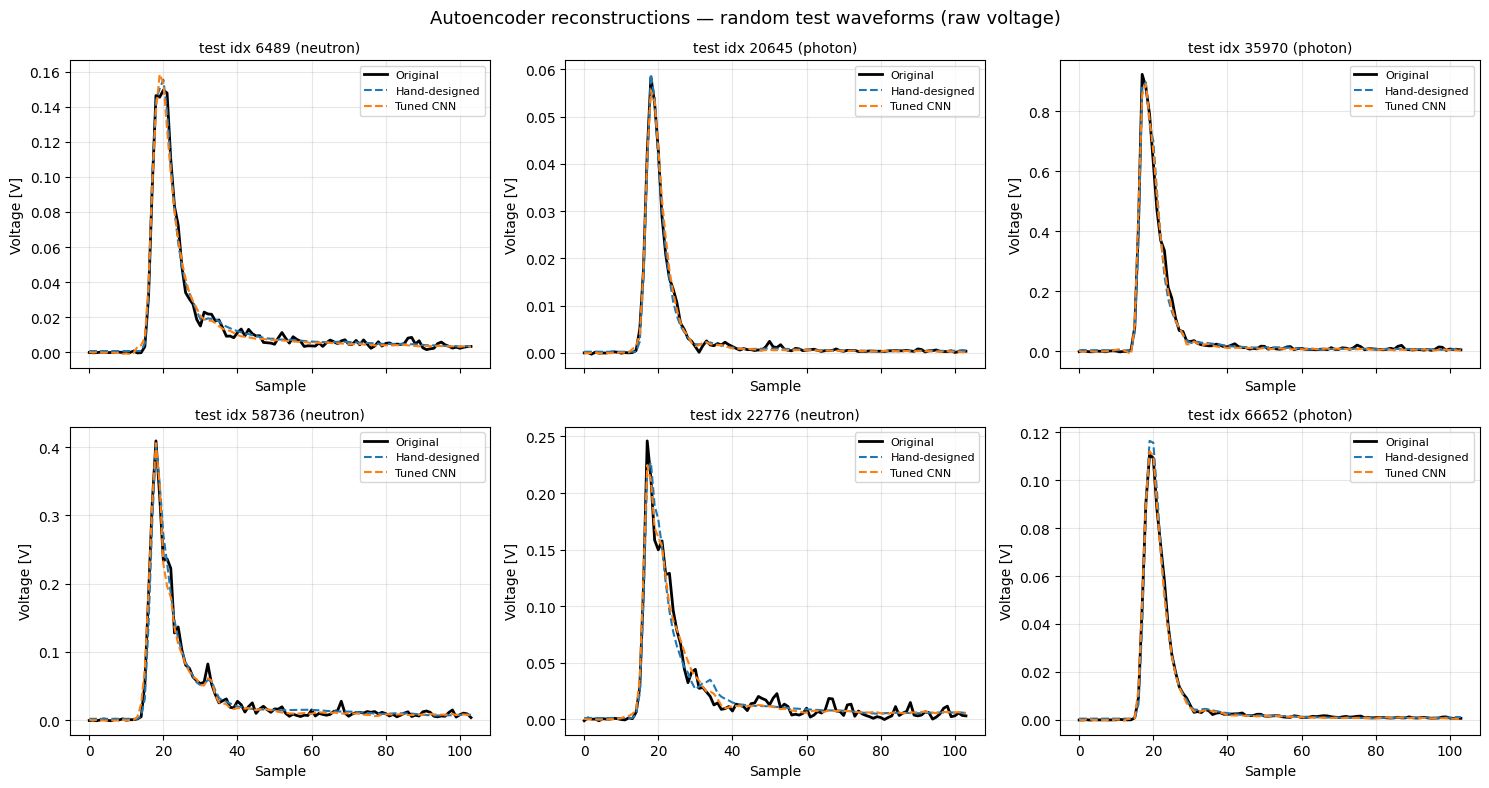

In [14]:
# Pick random test waveforms and plot original vs reconstructed for BOTH models.
n_plot = 6
rng_plot = np.random.default_rng()
indices = rng_plot.choice(X_test_n.shape[0], size=n_plot, replace=False)

# Predict with both models. Input/output shape is (N, 104, 1); squeeze last dim for plotting.
recon_old  = model.predict(X_test_n[indices], verbose=0)[0].squeeze(-1)
recon_tuned = tuned_model.predict(X_test_n[indices], verbose=0)[0].squeeze(-1)
orig_l2 = X_test_n[indices].squeeze(-1)

# Try to convert to raw voltage using the stored per-waveform L2 norms.
try:
    norms_all = np.load("processed_waveforms.npz")["X_norms"]
    _, norms_test = train_test_split(norms_all, test_size=0.2, stratify=y)
    sel_norms = norms_test[indices, None]
    orig_show   = orig_l2   * sel_norms
    old_show    = recon_old * sel_norms
    tuned_show  = recon_tuned * sel_norms
    ylabel = "Voltage [V]"
    scale_str = "raw voltage"
except KeyError:
    orig_show, old_show, tuned_show = orig_l2, recon_old, recon_tuned
    ylabel = "L2-normalized"
    scale_str = "L2-normalized space"

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()
for ax, row, idx in zip(axes, range(n_plot), indices):
    ax.plot(orig_show[row],  label="Original",       lw=2.0, color="black")
    ax.plot(old_show[row],   label="Hand-designed",  lw=1.5, linestyle="--", color="tab:blue")
    ax.plot(tuned_show[row], label="Tuned CNN",      lw=1.5, linestyle="--", color="tab:orange")
    label = "neutron" if Y_test[idx] == 1 else "photon"
    ax.set_title(f"test idx {idx} ({label})", fontsize=10)
    ax.set_xlabel("Sample")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle(f"Autoencoder reconstructions — random test waveforms ({scale_str})", fontsize=13)
plt.tight_layout()
plt.savefig("figures/a1_multitask_reconstructions.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
# Save the tuned model so a2_separator can load it for classification
tuned_model.save('a1_tuned.keras')
print('Tuned A1 model saved to a1_tuned.keras')


Tuned A1 model saved to a1_tuned.keras
